---
# Tugas UTS Mata Kuliah Pengolahan Citra Digital

### Kelompok 3
Anggota kelompok :
- Jeni Kasturi
- Aidil Farhan Rares
- Muhammad Zacky Desh Putra
---

Pengolahan dan Klasifikasi Gambar
Dataset: foto garpu (50), sendal (50), tisu basah (50)

Tujuan: Bersihkan kode, sediakan pipeline terstruktur, dan jalankan beberapa algoritma klasifikasi:
- Naïve Bayes (Bernoulli, Gaussian, Categorical, Multinomial, Complement)
- Logistic Regression
- Random Forest
- K-Nearest Neighbors (KNN)
- Neural Network / Deep Learning (CNN)


### Catatan:
- Notebook ini ditulis agar mudah dijalankan di Google Colab atau Jupyter.
- Pastikan dataset sudah terstruktur di Google Drive dalam folder: /content/drive/MyDrive/DatasetKelompok3/DatasetMZACKYDESHPUTRA dengan subfolder per kelas: 'garpu', 'sendal', 'tisu'.
- Jika struktur berbeda, sesuaikan path pada cell mount / data_dir.


---
## 1) Setup: import library dan mount Google Drive
Kita menggunakan beberapa library: os, glob untuk file; PIL/OpenCV untuk pemrosesan gambar; numpy/pandas untuk data; scikit-learn untuk model klasik; tensorflow/keras untuk CNN.

### Import Dataset
Kita import dataset terlebih dahulu dari Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Import Library

1.   Item daftar
2.   Item daftar


Setelah itu kita import library yang dibutuhkan


In [4]:
# -- Imports utama --
import os
import csv
import glob
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from google.colab.patches import cv2_imshow

# Image libs
from PIL import Image
import cv2

# Sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline

# Naive Bayes & classic models
from sklearn.naive_bayes import BernoulliNB, GaussianNB, CategoricalNB, MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# For categorical quantization
from sklearn.preprocessing import KBinsDiscretizer

# Keras for CNN
import tensorflow as tf
from tensorflow.keras import layers, models, utils

# Suppress warnings for clarity
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported")

Libraries imported


### Simpan dataset dalam bentuk Excel

In [5]:
# Simpan dataset sendal ke Excel
path = '/content/drive/MyDrive/DatasetKelompok3/DatasetMZACKYDESHPUTRA'
image_fitur=[]
for file in os.listdir(path):
  imag = cv2.imread(os.path.abspath(path + "/" + file),cv2.IMREAD_COLOR)

  # Check if the image was loaded successfully
  if imag is not None:
    imag = cv2.cvtColor(imag, cv2.COLOR_BGR2RGB)
    imag = cv2.cvtColor(imag, cv2.COLOR_RGB2GRAY)

    rata = np.mean(imag)
    stand = np.std(imag)
    vari = np.var(imag)
    skw = skew(skew(imag))

    fitur = (rata,stand,vari,skw)
    image_fitur.append(fitur)
  else:
    print(f"Warning: Could not load image file: {file}")

dt = pd.DataFrame(image_fitur,columns=['rata','standar','varian','skewness'])
dt.to_excel("Fitur Sandal.xlsx")

In [6]:
# Simpan dataset garpu ke Excel
path = '/content/drive/MyDrive/DatasetKelompok3/DatasetJENIKASTURI'
image_fitur=[]
for file in os.listdir(path):
  imag = cv2.imread(os.path.abspath(path + "/" + file),cv2.IMREAD_COLOR)

  # Check if the image was loaded successfully
  if imag is not None:
    imag = cv2.cvtColor(imag, cv2.COLOR_BGR2RGB)
    imag = cv2.cvtColor(imag, cv2.COLOR_RGB2GRAY)

    rata = np.mean(imag)
    stand = np.std(imag)
    vari = np.var(imag)
    skw = skew(skew(imag))

    fitur = (rata,stand,vari,skw)
    image_fitur.append(fitur)
  else:
    print(f"Warning: Could not load image file: {file}")

dt = pd.DataFrame(image_fitur,columns=['rata','standar','varian','skewness'])
dt.to_excel("Fitur Garpu.xlsx")

In [7]:
# Simpan dataset speaker ke Excel
path = '/content/drive/MyDrive/DatasetKelompok3/DatasetAIDIL'
image_fitur=[]
for file in os.listdir(path):
  imag = cv2.imread(os.path.abspath(path + "/" + file),cv2.IMREAD_COLOR)

  # Check if the image was loaded successfully
  if imag is not None:
    imag = cv2.cvtColor(imag, cv2.COLOR_BGR2RGB)
    imag = cv2.cvtColor(imag, cv2.COLOR_RGB2GRAY)

    rata = np.mean(imag)
    stand = np.std(imag)
    vari = np.var(imag)
    skw = skew(skew(imag))

    fitur = (rata,stand,vari,skw)
    image_fitur.append(fitur)
  else:
    print(f"Warning: Could not load image file: {file}")

dt = pd.DataFrame(image_fitur,columns=['rata','standar','varian','skewness'])
dt.to_excel("Fitur Speaker.xlsx")

In [ ]:
# Read dataset gabungan sandal & garpu
data = pd.read_excel('/content/drive/MyDrive/DatasetKelompok3/LABEL.xlsx')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   rata        100 non-null    float64
 2   standar     100 non-null    float64
 3   varian      100 non-null    float64
 4   skewness    100 non-null    float64
 5   label       100 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB


In [ ]:
# Memisahkan fitur X(input) & fitur Y(output)
x = data.iloc[:,:-1].values
y = data.iloc[:,-1].values

In [ ]:
# Memisahkan data Test & data Train
xtrain,xtes,ytrain,ytes = train_test_split(x,y,test_size=0.3,random_state=42)

In [ ]:
# Membuat model Bernoulli Naive Bayes dan melatihnya menggunakan data training
nb = BernoulliNB()
nb.fit(xtrain,ytrain)

BernoulliNB()

In [ ]:
# Hasil output model Bernoulli Naive Bayes
hasil = nb.predict(xtes)
print(hasil)

['Sandal' 'Sandal' 'Sandal' 'Sandal' 'Sandal' 'Garpu' 'Sandal' 'Sandal'
 'Sandal' 'Sandal' 'Garpu' 'Sandal' 'Sandal' 'Garpu' 'Sandal' 'Garpu'
 'Sandal' 'Sandal' 'Sandal' 'Garpu' 'Sandal' 'Garpu' 'Garpu' 'Sandal'
 'Sandal' 'Sandal' 'Garpu' 'Sandal' 'Sandal' 'Garpu']


In [ ]:
# Output data Xtes
print(xtes)

[[ 8.30000000e+01  1.33525049e+02  6.97666525e+01  4.86738580e+03
  -2.03395878e+00]
 [ 5.30000000e+01  1.36555054e+02  6.11252174e+01  3.73629220e+03
  -1.64722059e+00]
 [ 7.00000000e+01  1.07731281e+02  4.34152255e+01  1.88488181e+03
  -2.94786830e-01]
 [ 4.50000000e+01  2.07419710e+01  2.57726763e+01  6.64230845e+02
  -6.60121752e-01]
 [ 4.40000000e+01  1.71682243e+01  1.99600320e+01  3.98402877e+02
  -4.15819364e-01]
 [ 3.90000000e+01  1.66306299e+01  2.68067622e+01  7.18602500e+02
   1.85631244e-01]
 [ 2.20000000e+01  1.16409155e+01  1.08591605e+01  1.17921367e+02
  -5.24768686e-01]
 [ 8.00000000e+01  1.08080636e+02  7.45061093e+01  5.55116033e+03
  -1.33032712e+00]
 [ 1.00000000e+01  9.98031982e+00  1.18647835e+01  1.40773087e+02
  -1.80680452e+00]
 [ 0.00000000e+00  6.57728353e+00  1.11314800e+01  1.23909846e+02
  -1.23234245e+00]
 [ 1.80000000e+01  9.29961426e+00  2.23451721e+01  4.99306716e+02
   2.11987081e+00]
 [ 3.00000000e+01  7.22376628e+00  1.22583943e+01  1.50268231e+02

In [ ]:
# Hasil skor akurasi
akurasi = accuracy_score(hasil,ytes)
print(akurasi)

0.6


Confusion Matrix :
[[ 7 10]
 [ 2 11]]


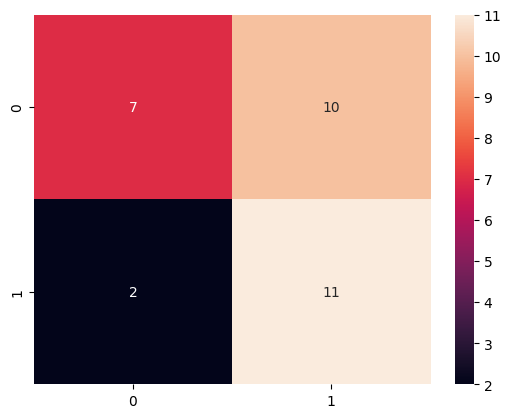

In [ ]:
# menampilkan Confusion Matrix dari hasil prediksi model klasifikasi, lalu menampilkannya dalam bentuk tabel dan visualisasi heatmap
cm=confusion_matrix(ytes, hasil)
print("Confusion Matrix :")
print(cm)

import seaborn as sns
sns.heatmap(cm,annot=True, fmt=".0f")
plt.show()

In [ ]:
xt = pd.DataFrame(xtes)
xt.to_excel('data_xtes.xlsx')

In [ ]:
yt = pd.DataFrame(ytes)
yt.to_excel('data_ytes.xlsx')

In [ ]:
yp = pd.DataFrame(hasil)
yp.to_excel('hasil_prediksi.xlsx')